<a href="https://colab.research.google.com/github/Raditya-Z/MachineLearning_244107020144/blob/main/QUIZ1/PerbandinganKsama-MetodeKmeans/K4_Studi_Kasus_KMeans_Cosine2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Setup Awal

In [69]:
import os
import time
import tracemalloc
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)

plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = 'outputKmeans'
os.makedirs(OUTPUT_DIR, exist_ok=True)

1. Data Understanding

1.1 Load Dataset

In [70]:
df = pd.read_csv('burnout_dataset1.csv')

df.head()

print(f'Jumlah data  : {df.shape[0]}')
print(f'Jumlah kolom : {df.shape[1]}')

Jumlah data  : 50000
Jumlah kolom : 40


1.2 Data Preview

In [71]:
print("5 Baris Pertama Dataset:")
display(df.head())

print("\nNama Semua Kolom:")
print(df.columns.tolist())

5 Baris Pertama Dataset:


,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,...,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,...,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,...,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,...,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low



Nama Semua Kolom:
['Person_ID', 'Age', 'Gender', 'Country', 'Occupation', 'Education_Level', 'Employment_Status', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Sleep_Quality', 'Stress_Level', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Exercise_Frequency', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score', 'Mental_Health_Status', 'AI_Wellness_Recommendation', 'Burnout_Risk']


1.3 Tipe data dan Missing Values

In [72]:
print('Tipe Data:')
print(df.dtypes)

print('\nJumlah Missing Value:')
missing = df.isnull().sum()

missing[missing > 0]

Tipe Data:
Person_ID                          int64
Age                              float64
Gender                            object
Country                           object
Occupation                        object
Education_Level                   object
Employment_Status                 object
Monthly_Income_USD               float64
Work_Hours_Per_Week                int64
Remote_Work                       object
Job_Satisfaction                 float64
Work_Life_Balance                float64
Sleep_Hours                      float64
Sleep_Quality                     object
Stress_Level                      object
Anxiety_Score                    float64
Depression_Score                 float64
Mood_Score                       float64
Emotional_Stability                int64
Physical_Activity_Hours          float64
Exercise_Frequency                object
Meditation_Minutes               float64
Screen_Time_Hours                float64
Social_Media_Hours               float64
Gamin

,0
Age,250
Monthly_Income_USD,1450
Job_Satisfaction,500
Work_Life_Balance,650
Sleep_Hours,950
Anxiety_Score,800
Depression_Score,850
Mood_Score,900
Physical_Activity_Hours,1100
Meditation_Minutes,1200


1.4 Identifikasi Kolom yang Digunakan

In [73]:
# Kolom numerik asli
numeric_columns = df.select_dtypes(include='number').columns

# Menghapus identifier
numeric_columns = numeric_columns.drop(
    ['Person_ID', 'Burnout_Score'],
    errors='ignore'
)

# Kolom kategorikal yang akan di-encoding
categorical_columns = [
    'Remote_Work',
    'Sleep_Quality',
    'Stress_Level',
    'Exercise_Frequency',
    'Alcohol_Consumption',
    'Smoking',
    'Healthy_Diet',
    'Chronic_Stress',
    'Family_History_Mental_Illness',
    'Therapy_Attendance',
    'Support_System',
    'Mental_Health_Status'
]

print('Kolom Numerik:')
print(numeric_columns.tolist())

print('\nKolom Kategorikal yang akan di-encoding:')
print(categorical_columns)

Kolom Numerik:
['Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days']

Kolom Kategorikal yang akan di-encoding:
['Remote_Work', 'Sleep_Quality', 'Stress_Level', 'Exercise_Frequency', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Mental_Health_Status']


1.5 Statistik Deskriptif

In [74]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,49750.0,41.448181,13.871634,18.0,29.0,41.0,53.0,65.0
Monthly_Income_USD,48550.0,6251.281524,3319.661435,500.0,3381.0,6231.0,9134.0,12000.0
Work_Hours_Per_Week,50000.0,44.946160,14.729024,20.0,32.0,45.0,58.0,70.0
Job_Satisfaction,49500.0,5.499051,2.866621,1.0,3.0,6.0,8.0,10.0
Work_Life_Balance,49350.0,5.504397,2.867492,1.0,3.0,6.0,8.0,10.0
Sleep_Hours,49050.0,6.997445,1.728766,4.0,5.5,7.0,8.5,10.0
Anxiety_Score,49200.0,40.449045,26.004291,0.0,19.0,39.0,59.0,100.0
Depression_Score,49150.0,40.601160,26.308933,0.0,19.0,39.0,60.0,100.0
Mood_Score,49100.0,59.622994,25.783486,0.0,41.0,61.0,80.0,100.0
Emotional_Stability,50000.0,59.382100,26.090946,0.0,40.0,60.0,81.0,100.0


1.6 Visualisasi Distribusi Data

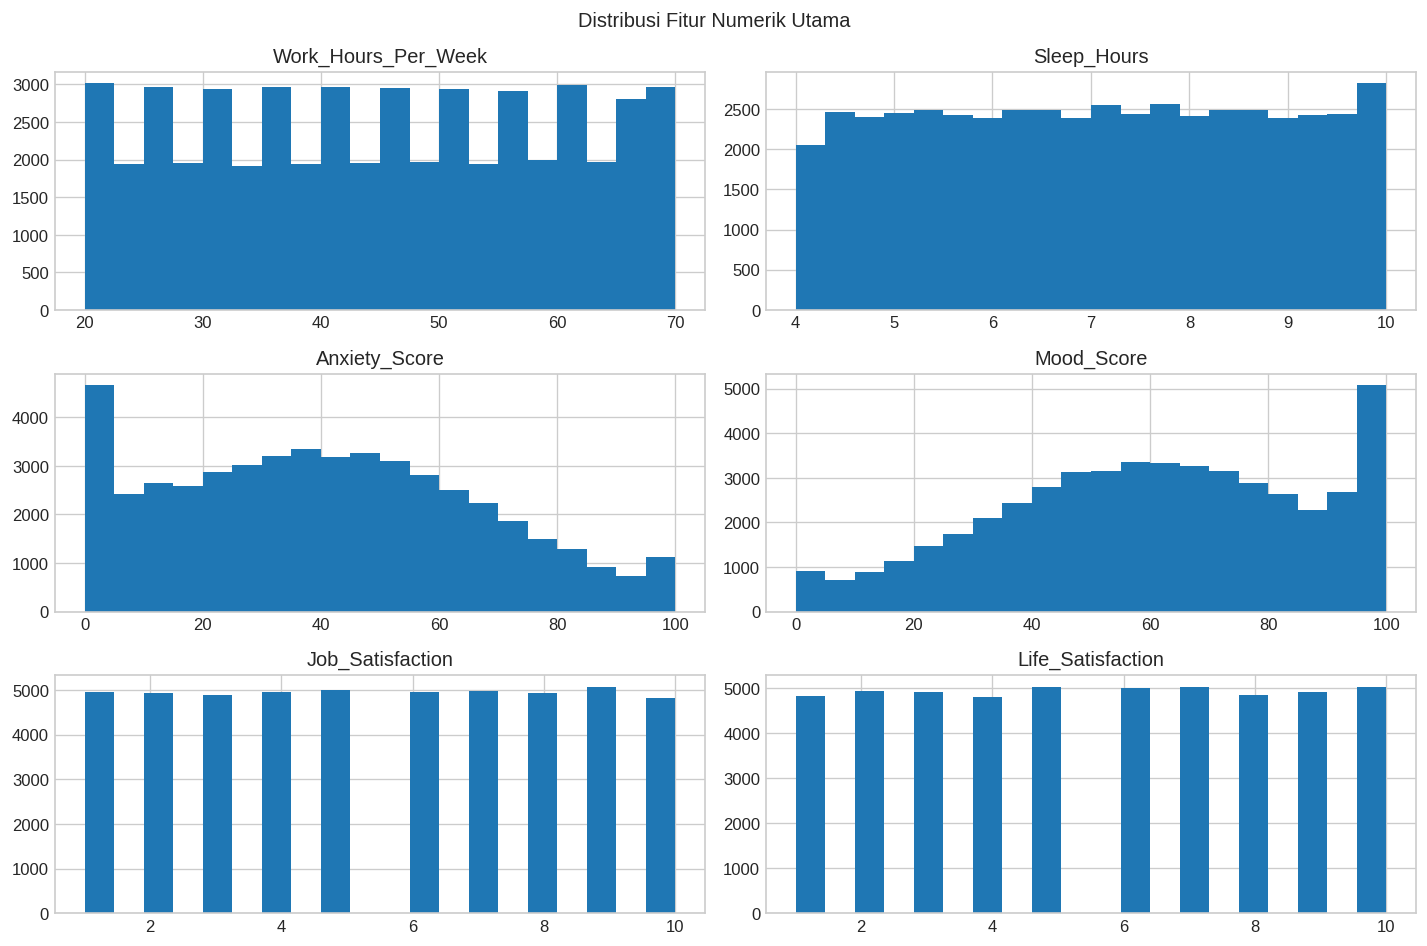

In [75]:
selected_features = [
    'Work_Hours_Per_Week',
    'Sleep_Hours',
    'Anxiety_Score',
    'Mood_Score',
    'Job_Satisfaction',
    'Life_Satisfaction'
]

df[selected_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle('Distribusi Fitur Numerik Utama')
plt.tight_layout()
plt.show()

1.7 Visualisasi Deteksi Outlier

In [76]:
numeric_columns_outlier = df.select_dtypes(
    include='number'
).columns

numeric_columns_outlier = numeric_columns_outlier.drop(
    ['Person_ID', 'Burnout_Score'],
    errors='ignore'
)

numeric_data = df[numeric_columns_outlier]

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (numeric_data < lower_bound) |
    (numeric_data > upper_bound)
)

In [77]:
outlier_summary = pd.DataFrame({
    'Jumlah Outlier': outlier_mask.sum(),
    'Persentase (%)': (
        outlier_mask.sum() / len(df) * 100
    ).round(2)
})

outlier_summary = outlier_summary.sort_values(
    'Jumlah Outlier',
    ascending=False
)

outlier_summary

,Jumlah Outlier,Persentase (%)
Age,0,0.0
Monthly_Income_USD,0,0.0
Work_Hours_Per_Week,0,0.0
Job_Satisfaction,0,0.0
Work_Life_Balance,0,0.0
Sleep_Hours,0,0.0
Anxiety_Score,0,0.0
Depression_Score,0,0.0
Mood_Score,0,0.0
Emotional_Stability,0,0.0


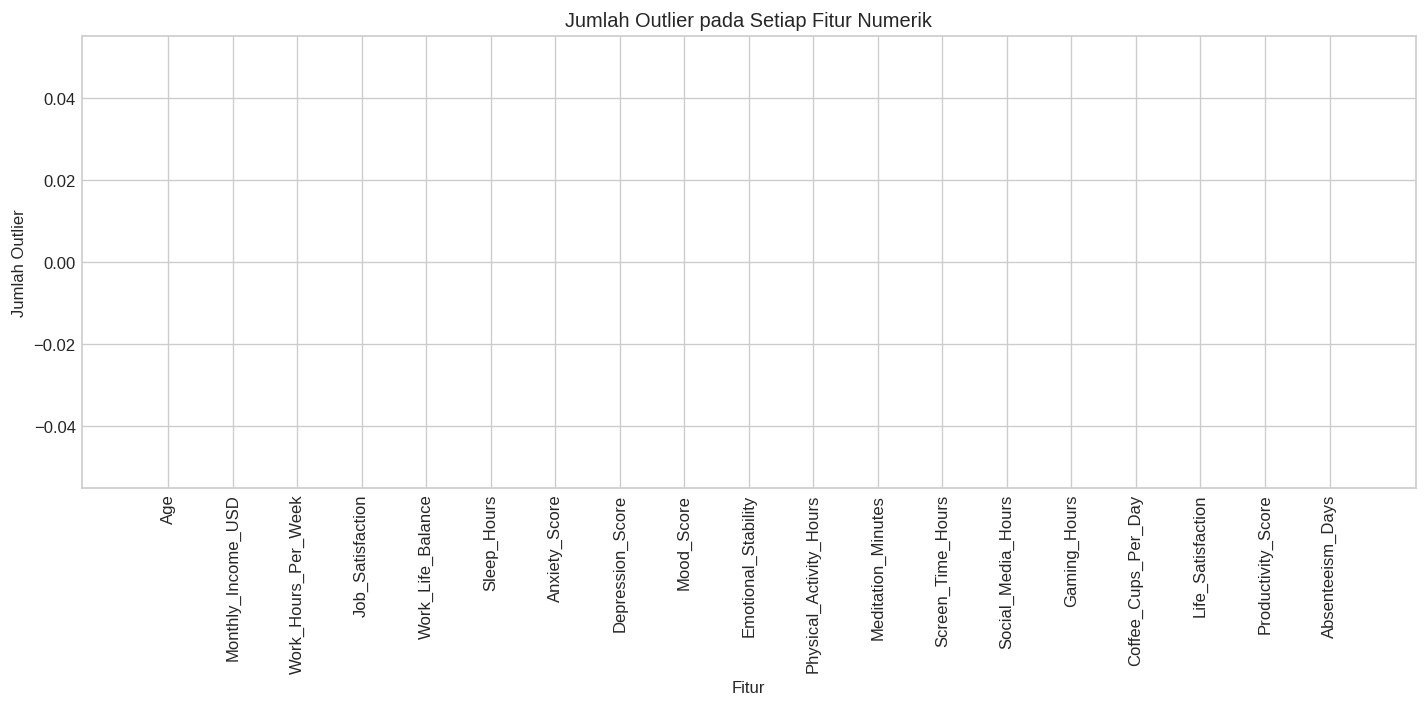

In [78]:
plt.figure(figsize=(12, 6))

plt.bar(
    outlier_summary.index,
    outlier_summary['Jumlah Outlier']
)

plt.title('Jumlah Outlier pada Setiap Fitur Numerik')
plt.xlabel('Fitur')
plt.ylabel('Jumlah Outlier')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [79]:
print(outlier_summary)

                         Jumlah Outlier  Persentase (%)
Age                                   0             0.0
Monthly_Income_USD                    0             0.0
Work_Hours_Per_Week                   0             0.0
Job_Satisfaction                      0             0.0
Work_Life_Balance                     0             0.0
Sleep_Hours                           0             0.0
Anxiety_Score                         0             0.0
Depression_Score                      0             0.0
Mood_Score                            0             0.0
Emotional_Stability                   0             0.0
Physical_Activity_Hours               0             0.0
Meditation_Minutes                    0             0.0
Screen_Time_Hours                     0             0.0
Social_Media_Hours                    0             0.0
Gaming_Hours                          0             0.0
Coffee_Cups_Per_Day                   0             0.0
Life_Satisfaction                     0         

2.1 Seleksi Kolom

In [80]:
selected_columns = list(numeric_columns) + categorical_columns

X = df[selected_columns].copy()

X.head()

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,58.0,2786.0,67,3.0,7.0,4.6,74.0,75.0,26.0,18,...,High,Weekly,Yes,Yes,No,Yes,No,Yes,Average,Critical
1,24.0,8027.0,44,5.0,8.0,4.7,58.0,80.0,29.0,37,...,Moderate,Weekly,Yes,Yes,Yes,No,Yes,No,Good,Critical
2,59.0,3177.0,60,8.0,7.0,6.3,54.0,55.0,44.0,48,...,Moderate,Daily,Yes,No,No,No,Yes,No,Average,Needs Attention
3,65.0,4093.0,25,2.0,9.0,7.1,12.0,11.0,88.0,80,...,Low,Weekly,Yes,No,No,No,No,Yes,Good,Healthy
4,64.0,NaN,52,1.0,4.0,9.1,25.0,48.0,67.0,76,...,Low,Never,Yes,No,No,No,Yes,No,Poor,Healthy


2.2 Encoding Data Kategorikal

In [81]:
encoding_maps = {
    'Remote_Work': {
        'No': 0,
        'Hybrid': 1,
        'Yes': 2
    },

    'Sleep_Quality': {
        'Excellent': 0,
        'Good': 1,
        'Average': 2,
        'Poor': 3
    },

    'Stress_Level': {
        'Low': 0,
        'Moderate': 1,
        'High': 2
    },

    'Exercise_Frequency': {
        'Daily': 0,
        'Weekly': 1,
        'Rarely': 2,
        'Never': 3
    },

    'Alcohol_Consumption': {
        'No': 0,
        'Yes': 1
    },

    'Smoking': {
        'No': 0,
        'Yes': 1
    },

    'Healthy_Diet': {
        'No': 0,
        'Yes': 1
    },

    'Chronic_Stress': {
        'No': 0,
        'Yes': 1
    },

    'Family_History_Mental_Illness': {
        'No': 0,
        'Yes': 1
    },

    'Therapy_Attendance': {
        'No': 0,
        'Yes': 1
    },

    'Support_System': {
        'Poor': 0,
        'Average': 1,
        'Good': 2,
        'Excellent': 3
    },

    'Mental_Health_Status': {
        'Healthy': 0,
        'Needs Attention': 1,
        'Critical': 2
    }
}

for column, mapping in encoding_maps.items():
    X[column] = X[column].map(mapping)

X[categorical_columns].head()

,Remote_Work,Sleep_Quality,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1,3,2,1,1,1,0,1,0,1.0,1,2
1,1,3,1,1,1,1,1,0,1,0.0,2,2
2,0,2,1,0,1,0,0,0,1,0.0,1,1
3,2,1,0,1,1,0,0,0,0,1.0,2,0
4,0,0,0,3,1,0,0,0,1,0.0,0,0


2.3 Penanganan Missing Values

In [82]:
print('Missing value sebelum preprocessing:')
print(X.isnull().sum())

X = X.fillna(X.median())

print(
    '\nJumlah missing value setelah preprocessing:',
    X.isnull().sum().sum()
)

Missing value sebelum preprocessing:
Age                               250
Monthly_Income_USD               1450
Work_Hours_Per_Week                 0
Job_Satisfaction                  500
Work_Life_Balance                 650
Sleep_Hours                       950
Anxiety_Score                     800
Depression_Score                  850
Mood_Score                        900
Emotional_Stability                 0
Physical_Activity_Hours          1100
Meditation_Minutes               1200
Screen_Time_Hours                 850
Social_Media_Hours                600
Gaming_Hours                      750
Coffee_Cups_Per_Day                 0
Life_Satisfaction                 700
Productivity_Score                950
Absenteeism_Days                    0
Remote_Work                         0
Sleep_Quality                       0
Stress_Level                        0
Exercise_Frequency                  0
Alcohol_Consumption                 0
Smoking                             0
Healthy_Diet 

2.4 Penanganan Outlier

In [83]:
# Karena tidak, tidak dilakukan

2.5 Standardisasi

In [84]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1.196378,-1.059170,1.497320,-0.877799,0.522638,-1.400203,1.301535,1.319769,-1.316899,-1.586087,...,1.838578,-0.455507,1.008436,1.003687,-0.996685,2.53389,-0.996765,1.016577,-0.441976,1.633584
1,-1.260836,0.543024,-0.064238,-0.176698,0.873599,-1.341801,0.681279,1.511451,-1.199485,-0.857858,...,0.411952,-0.455507,1.008436,1.003687,1.003326,-0.39465,1.003245,-0.983693,0.452894,1.633584
2,1.268649,-0.939640,1.022063,0.874952,0.522638,-0.407356,0.526215,0.553042,-0.612419,-0.436251,...,0.411952,-1.351150,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-0.441976,0.373764
3,1.702275,-0.659615,-1.354221,-1.228349,1.224560,0.059866,-1.101957,-1.133757,1.109642,0.790240,...,-1.014673,-0.455507,1.008436,-0.996327,-0.996685,-0.39465,-0.996765,1.016577,0.452894,-0.886057
4,1.630004,-0.006020,0.478912,-1.578899,-0.530247,1.227922,-0.597999,0.284688,0.287749,0.636928,...,-1.014673,1.335781,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-1.336847,-0.886057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-0.393584,-0.828669,-0.132132,0.874952,0.171676,0.001464,0.642513,0.323024,-0.573281,-0.551235,...,0.411952,-0.455507,1.008436,-0.996327,1.003326,-0.39465,1.003245,-0.983693,-0.441976,0.373764
49996,1.124107,1.338771,-1.422115,-1.228349,0.171676,-1.575412,-1.334553,-1.555457,1.305331,1.556797,...,-1.014673,-1.351150,1.008436,1.003687,-0.996685,-0.39465,-0.996765,1.016577,1.347764,-0.886057
49997,-0.538126,-0.950034,0.750488,0.874952,-1.232169,0.351880,0.952641,1.434779,-1.042934,-1.011169,...,0.411952,1.335781,1.008436,-0.996327,1.003326,-0.39465,-0.996765,1.016577,-1.336847,1.633584
49998,1.413191,-0.754995,-1.082646,-0.176698,0.522638,0.001464,-0.326637,-0.903739,0.561714,0.100338,...,-1.014673,1.335781,1.008436,1.003687,-0.996685,-0.39465,-0.996765,1.016577,-1.336847,-0.886057


2.6 Data Bersih

In [85]:
print('Dimensi data setelah preprocessing:', X.shape)
print('Jumlah missing value:', X.isnull().sum().sum())

X_scaled.head()

Dimensi data setelah preprocessing: (50000, 31)
Jumlah missing value: 0


,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1.196378,-1.059170,1.497320,-0.877799,0.522638,-1.400203,1.301535,1.319769,-1.316899,-1.586087,...,1.838578,-0.455507,1.008436,1.003687,-0.996685,2.53389,-0.996765,1.016577,-0.441976,1.633584
1,-1.260836,0.543024,-0.064238,-0.176698,0.873599,-1.341801,0.681279,1.511451,-1.199485,-0.857858,...,0.411952,-0.455507,1.008436,1.003687,1.003326,-0.39465,1.003245,-0.983693,0.452894,1.633584
2,1.268649,-0.939640,1.022063,0.874952,0.522638,-0.407356,0.526215,0.553042,-0.612419,-0.436251,...,0.411952,-1.351150,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-0.441976,0.373764
3,1.702275,-0.659615,-1.354221,-1.228349,1.224560,0.059866,-1.101957,-1.133757,1.109642,0.790240,...,-1.014673,-0.455507,1.008436,-0.996327,-0.996685,-0.39465,-0.996765,1.016577,0.452894,-0.886057
4,1.630004,-0.006020,0.478912,-1.578899,-0.530247,1.227922,-0.597999,0.284688,0.287749,0.636928,...,-1.014673,1.335781,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-1.336847,-0.886057


3. Modeling


3.1 Penentuan Jumlah Klaster dengan Elbow Method


### Fungsi K-Means Cosine

Implementasi menggunakan **Cosine Distance**. Centroid diperbarui dari rata-rata anggota cluster kemudian dinormalisasi kembali agar sesuai dengan konsep **Spherical K-Means**. Struktur eksperimen dibuat sejajar dengan K-Means Euclidean agar hasil keduanya dapat dibandingkan secara lebih konsisten.


In [86]:
class KMeansCosine:
    def __init__(
        self,
        n_clusters=3,
        max_iter=300,
        tol=1e-4,
        random_state=42
    ):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = 0.0
        self.n_iter_ = 0

    def _normalize(self, X):
        X = np.asarray(X, dtype=float)
        norms = np.linalg.norm(
            X,
            axis=1,
            keepdims=True
        )
        norms[norms == 0] = 1e-10
        return X / norms

    def _compute_distance(
        self,
        X,
        centroids
    ):
        return pairwise_distances(
            X,
            centroids,
            metric='cosine'
        )

    def _init_centroids(self, X):
        rng = np.random.RandomState(
            self.random_state
        )

        n_samples = X.shape[0]

        first_idx = rng.randint(
            n_samples
        )

        centroids = [
            X[first_idx]
        ]

        for _ in range(
            1,
            self.n_clusters
        ):
            current_centroids = np.array(
                centroids
            )

            distances = self._compute_distance(
                X,
                current_centroids
            )

            min_distances = np.min(
                distances,
                axis=1
            )

            squared_distances = (
                min_distances ** 2
            )

            total = np.sum(
                squared_distances
            )

            if total == 0:
                probabilities = (
                    np.ones(n_samples)
                    / n_samples
                )
            else:
                probabilities = (
                    squared_distances
                    / total
                )

            next_idx = rng.choice(
                n_samples,
                p=probabilities
            )

            centroids.append(
                X[next_idx]
            )

        return self._normalize(
            np.array(centroids)
        )

    def fit(self, X):
        X_array = np.asarray(
            X,
            dtype=float
        )

        X_norm = self._normalize(
            X_array
        )

        centroids = self._init_centroids(
            X_norm
        )

        rng = np.random.RandomState(
            self.random_state
        )

        for iteration in range(
            self.max_iter
        ):
            distances = self._compute_distance(
                X_norm,
                centroids
            )

            labels = np.argmin(
                distances,
                axis=1
            )

            new_centroids = np.zeros_like(
                centroids
            )

            for cluster in range(
                self.n_clusters
            ):
                cluster_points = X_norm[
                    labels == cluster
                ]

                if len(cluster_points) == 0:
                    new_centroids[cluster] = (
                        X_norm[
                            rng.randint(
                                len(X_norm)
                            )
                        ]
                    )
                else:
                    mean_vector = np.mean(
                        cluster_points,
                        axis=0
                    )

                    norm = np.linalg.norm(
                        mean_vector
                    )

                    if norm == 0:
                        new_centroids[cluster] = (
                            mean_vector
                        )
                    else:
                        new_centroids[cluster] = (
                            mean_vector / norm
                        )

            shift = np.linalg.norm(
                new_centroids - centroids
            )

            centroids = new_centroids

            if shift < self.tol:
                break

        final_distances = self._compute_distance(
            X_norm,
            centroids
        )

        labels = np.argmin(
            final_distances,
            axis=1
        )

        assigned_distances = (
            final_distances[
                np.arange(len(X_norm)),
                labels
            ]
        )

        self.cluster_centers_ = centroids
        self.labels_ = labels
        self.inertia_ = float(
            np.sum(assigned_distances)
        )
        self.n_iter_ = iteration + 1

        return self


In [87]:
k_values = list(range(1, 11))
cosine_inertia = []

for k in k_values:
    model_test = KMeansCosine(
        n_clusters=k,
        max_iter=300,
        tol=1e-4,
        random_state=42
    )

    model_test.fit(
        X_scaled
    )

    cosine_inertia.append(
        model_test.inertia_
    )


In [88]:
p1 = np.array([
    k_values[0],
    cosine_inertia[0]
])

p2 = np.array([
    k_values[-1],
    cosine_inertia[-1]
])

line_vec = p2 - p1
line_unit = (
    line_vec
    / np.linalg.norm(line_vec)
)

distances_elbow = []

for k, inertia in zip(
    k_values,
    cosine_inertia
):
    point = np.array([
        k,
        inertia
    ])

    vec = point - p1

    projection = (
        np.dot(
            vec,
            line_unit
        )
        * line_unit
    )

    perpendicular = (
        vec - projection
    )

    distances_elbow.append(
        np.linalg.norm(
            perpendicular
        )
    )

n_clusters = 3

print(
    f'Jumlah Cluster untuk Pengujian: '
    f'k = {n_clusters}'
)

print(
    f'Jumlah Cluster Optimal: '
    f'k = {n_clusters}'
)


Jumlah Cluster untuk Pengujian: k = 3
Jumlah Cluster Optimal: k = 3


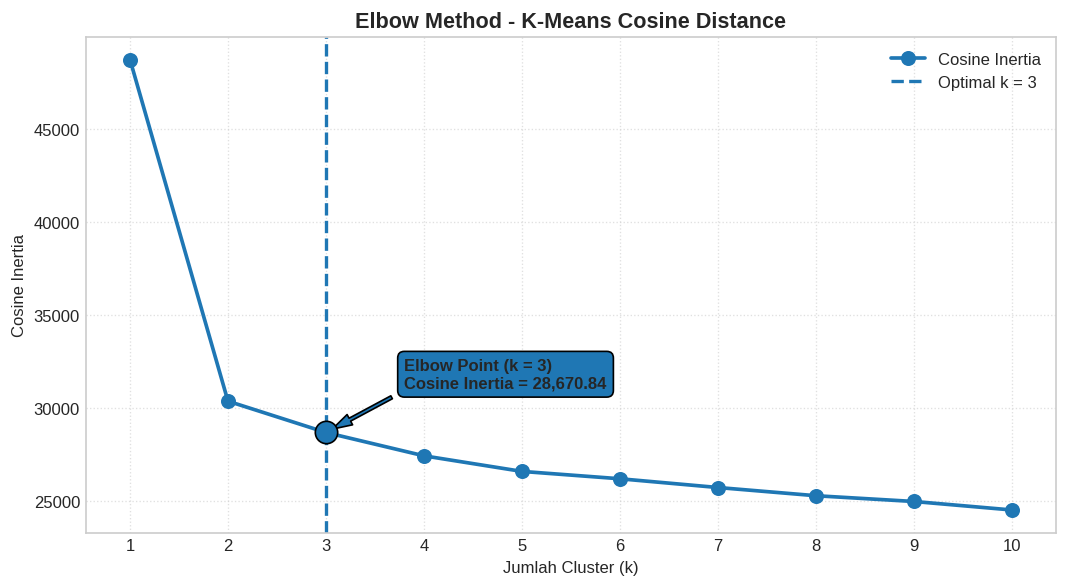

In [89]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    k_values,
    cosine_inertia,
    marker='o',
    markersize=8,
    linewidth=2.2,
    label='Cosine Inertia'
)

plt.axvline(
    x=n_clusters,
    linestyle='--',
    linewidth=2,
    label=f'Optimal k = {n_clusters}'
)

plt.scatter(
    [n_clusters],
    [
        cosine_inertia[
            n_clusters - 1
        ]
    ],
    s=180,
    zorder=5,
    edgecolor='black'
)

plt.title(
    'Elbow Method - K-Means Cosine Distance',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel(
    'Jumlah Cluster (k)'
)

plt.ylabel(
    'Cosine Inertia'
)

plt.xticks(
    k_values
)

plt.annotate(
    f'Elbow Point (k = {n_clusters})\n'
    f'Cosine Inertia = '
    f'{cosine_inertia[n_clusters - 1]:,.2f}',
    xy=(
        n_clusters,
        cosine_inertia[
            n_clusters - 1
        ]
    ),
    xytext=(
        n_clusters + 0.8,
        cosine_inertia[
            n_clusters - 1
        ]
        + (
            max(cosine_inertia)
            - min(cosine_inertia)
        ) * 0.1
    ),
    arrowprops=dict(
        shrink=0.08,
        width=2,
        headwidth=7
    ),
    bbox=dict(
        boxstyle='round,pad=0.4'
    ),
    fontweight='bold'
)

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        'elbow_cosine.png'
    ),
    dpi=300
)

plt.show()


3.2 Training K-Means Cosine


In [90]:
tracemalloc.start()

start_time = time.perf_counter()

kmeans_cosine = KMeansCosine(
    n_clusters=n_clusters,
    max_iter=300,
    tol=1e-4,
    random_state=42
)

kmeans_cosine.fit(
    X_scaled
)

runtime = (
    time.perf_counter()
    - start_time
)

current_memory, peak_memory = (
    tracemalloc.get_traced_memory()
)

tracemalloc.stop()

peak_memory_mb = (
    peak_memory / (1024 ** 2)
)

labels = (
    kmeans_cosine.labels_
)

df['KMeans_Cluster'] = labels


In [91]:
iterations = (
    kmeans_cosine.n_iter_
)

cosine_inertia_final = (
    kmeans_cosine.inertia_
)

print(
    f'Runtime        : '
    f'{runtime:.5f} detik'
)

print(
    f'Iterations     : '
    f'{iterations}'
)

print(
    f'Cosine Inertia : '
    f'{cosine_inertia_final:.2f}'
)

print(
    f'Peak Memory    : '
    f'{peak_memory_mb:.2f} MB'
)


Runtime        : 1.56065 detik
Iterations     : 29
Cosine Inertia : 28670.84
Peak Memory    : 30.25 MB


4. Evaluasi


4.1 Silhouette Score


In [92]:
silhouette = float(
    silhouette_score(
        X_scaled,
        labels,
        metric='cosine'
    )
)

print(
    f'Silhouette Score: '
    f'{silhouette:.4f}'
)


Silhouette Score: 0.1666


4.2 Davies-Bouldin Index


In [93]:
db_index = float(
    davies_bouldin_score(
        X_scaled,
        labels
    )
)

print(
    f'Davies-Bouldin Index: '
    f'{db_index:.4f}'
)


Davies-Bouldin Index: 3.2553


4.3 Calinski-Harabasz Index


In [94]:
ch_index = float(
    calinski_harabasz_score(
        X_scaled,
        labels
    )
)

print(
    f'Calinski-Harabasz Index: '
    f'{ch_index:.2f}'
)


Calinski-Harabasz Index: 6147.10


4.4 Distribusi Cluster


In [95]:
cluster_distribution = (
    df['KMeans_Cluster']
    .value_counts()
    .sort_index()
)

cluster_distribution


,count
KMeans_Cluster,
0,11960
1,21584
2,16456


4.5 Ringkasan Evaluasi


In [96]:
model_summary = pd.DataFrame([{
    'Model':
        'K-Means Cosine',

    'Distance Metric':
        'Cosine Distance',

    'Jumlah Cluster':
        n_clusters,

    'Silhouette Score (↑)':
        round(
            silhouette,
            4
        ),

    'Davies-Bouldin Index (↓)':
        round(
            db_index,
            4
        ),

    'Calinski-Harabasz Index (↑)':
        round(
            ch_index,
            2
        ),

    'Execution Time (s) (↓)':
        round(
            runtime,
            5
        ),

    'Iterations (↓)':
        iterations,

    'Objective Value (Cosine Inertia) (↓)':
        round(
            cosine_inertia_final,
            2
        ),

    'Alokasi Memori (MB)':
        round(
            peak_memory_mb,
            2
        )
}])

model_summary


,Model,Distance Metric,Jumlah Cluster,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),Execution Time (s) (↓),Iterations (↓),Objective Value (Cosine Inertia) (↓),Alokasi Memori (MB)
0,K-Means Cosine,Cosine Distance,3,0.1666,3.2553,6147.1,1.56065,29,28670.84,30.25


4.6 Export Hasil


In [97]:
excel_path = os.path.join(
    OUTPUT_DIR,
    'evaluasi_kmeans_cosine.xlsx'
)

df_clustered = df.copy()

df_clustered[
    'KMeans_Cluster'
] = labels

with pd.ExcelWriter(
    excel_path,
    engine='openpyxl'
) as writer:

    model_summary.to_excel(
        writer,
        sheet_name='Ringkasan_Evaluasi',
        index=False
    )

    df_clustered.to_excel(
        writer,
        sheet_name='Data_Terklaster',
        index=False
    )

print(
    f'Hasil disimpan ke: '
    f'{excel_path}'
)


Hasil disimpan ke: outputKmeans/evaluasi_kmeans_cosine.xlsx


5. Reduksi Dimensi PCA


5.1 PCA


In [98]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

centroids_pca = pca.transform(
    kmeans_cosine.cluster_centers_
)


5.2 Visualisasi Hasil Klaster


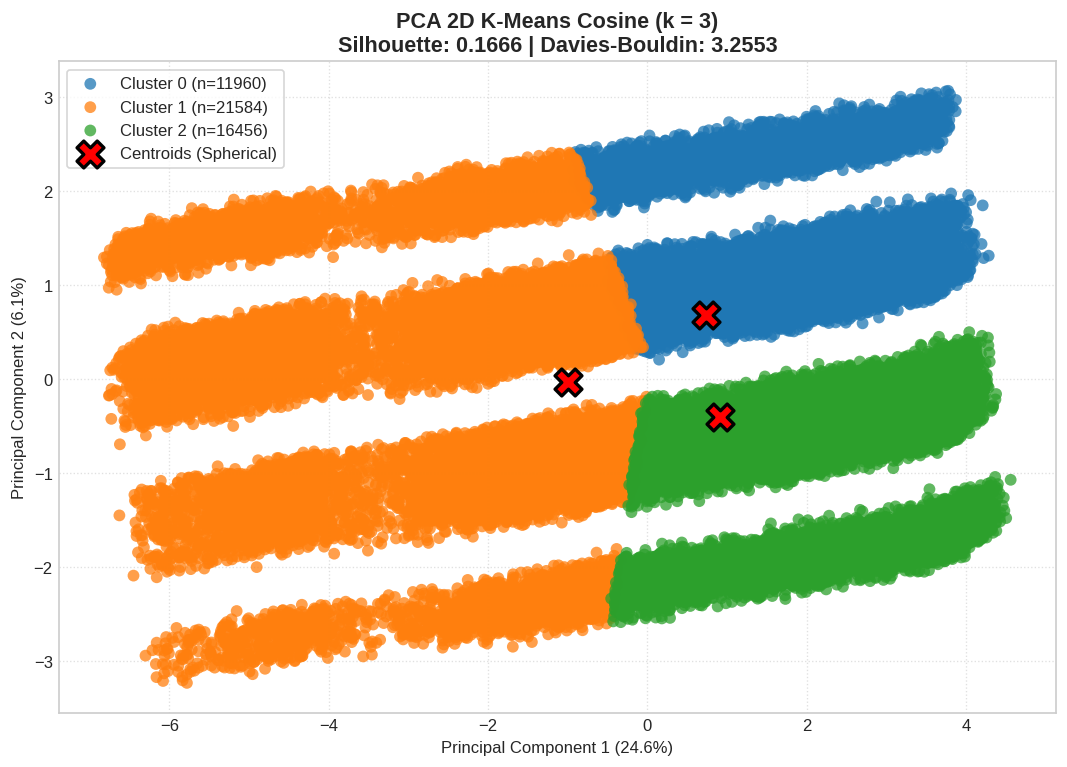

In [99]:
plt.figure(
    figsize=(9, 6.5)
)

palette = sns.color_palette(
    'tab10',
    n_clusters
)

for k in range(
    n_clusters
):
    mask = labels == k

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        color=palette[k],
        label=(
            f'Cluster {k} '
            f'(n={np.sum(mask)})'
        ),
        alpha=0.75,
        s=50,
        edgecolors='none'
    )

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=260,
    c='red',
    edgecolor='black',
    linewidth=2,
    label='Centroids (Spherical)',
    zorder=10
)

plt.title(
    f'PCA 2D K-Means Cosine '
    f'(k = {n_clusters})\n'
    f'Silhouette: {silhouette:.4f} | '
    f'Davies-Bouldin: {db_index:.4f}',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel(
    'Principal Component 1 '
    f'({pca.explained_variance_ratio_[0] * 100:.1f}%)'
)

plt.ylabel(
    'Principal Component 2 '
    f'({pca.explained_variance_ratio_[1] * 100:.1f}%)'
)

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

plt.legend(
    frameon=True,
    loc='best'
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        'cluster_cosine.png'
    ),
    dpi=300
)

plt.show()


6. Analisis


6.1 Profil Cluster


In [100]:
df_analysis = X.copy()

df_analysis[
    'KMeans_Cluster'
] = labels

cluster_profile = (
    df_analysis
    .groupby(
        'KMeans_Cluster'
    )
    .mean()
)

cluster_profile


,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,41.515134,6263.931438,36.018980,5.511873,5.526756,5.522007,24.527007,24.882860,75.218144,75.509281,...,0.284950,1.502090,0.493813,0.494900,0.502341,0.000000,0.498829,0.495067,1.479431,0.155100
1,41.465854,6217.965993,54.400713,5.499676,5.517189,6.649189,64.203855,64.127039,36.131950,35.339511,...,1.331171,1.522517,0.499954,0.502178,0.492263,0.312176,0.498981,0.491058,1.497405,1.454086
2,41.369531,6283.997934,39.033544,5.504132,5.490946,8.526702,20.793267,21.085318,79.175255,79.195795,...,0.207948,1.495017,0.491796,0.495260,0.503403,0.000000,0.497265,0.490338,1.499818,0.117039


6.2 Perbandingan Cluster dengan Burnout Risk


In [101]:
comparison = pd.crosstab(
    df['KMeans_Cluster'],
    df['Burnout_Risk']
)

comparison

comparison_percentage = pd.crosstab(
    df['KMeans_Cluster'],
    df['Burnout_Risk'],
    normalize='index'
) * 100

comparison_percentage.round(2)


Burnout_Risk,High,Low,Moderate
KMeans_Cluster,,,
0,0.00,84.49,15.51
1,45.64,3.40,50.96
2,0.00,88.30,11.70


6.3 Analisis Centroid


In [102]:
centroid_standardized = (
    kmeans_cosine.cluster_centers_
)

centroid_original = (
    scaler.inverse_transform(
        centroid_standardized
    )
)

centroid_original = pd.DataFrame(
    centroid_original,
    columns=X.columns
)

centroid_original.index.name = (
    'Cluster'
)

centroid_original


,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
Cluster,,,,,,,,,,,,,,,,,,,,,
0,41.468338,6257.619956,40.966493,5.505936,5.517685,6.320512,33.437610,33.670353,66.483606,66.478399,...,0.521903,1.505181,0.494906,0.496869,0.500544,0.072087,0.498757,0.493152,1.487538,0.453310
1,41.456033,6234.380027,48.662851,5.499619,5.513341,6.867937,49.585075,49.648540,50.589504,50.111387,...,0.946330,1.514000,0.497286,0.500083,0.496011,0.182722,0.498353,0.491213,1.495792,0.993670
2,41.420487,6265.296254,42.616932,5.504535,5.501045,7.637090,32.499734,32.695871,67.525001,67.395371,...,0.504977,1.503178,0.494303,0.496831,0.500580,0.077301,0.497812,0.491263,1.496783,0.457859
